In [62]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb_model import GRSC_CB_Model
from grsc_cb_instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay, ConvexHull
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
# number of land parcels
n = 30
# number of species
m = 10
# number of max connected areas
k = 1
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 1
# tau
tau = 0.5

External nodes: [3, 6, 9, 10, 21, 22, 24, 29]


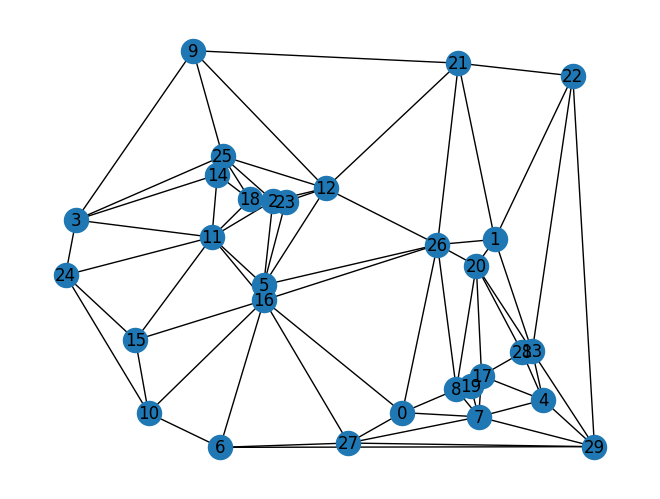

In [64]:
# generate a random instance Delunay graph
points = np.random.rand(n, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, h = simplex
    G.add_edge(i, j)
    G.add_edge(j, h)
    G.add_edge(i, h)

# determines the set of external nodes  
external_nodes = set(ConvexHull(points).vertices)
nx.draw(G, points, with_labels=True)
print(f"External nodes: {[int(i) for i in external_nodes]}")

In [65]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [66]:
# specie definition
S_1 = list(range(m//3))
S_2 = list(range(m//3, m))
P_1 = len(S_1)
P_2 = len(S_2)

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

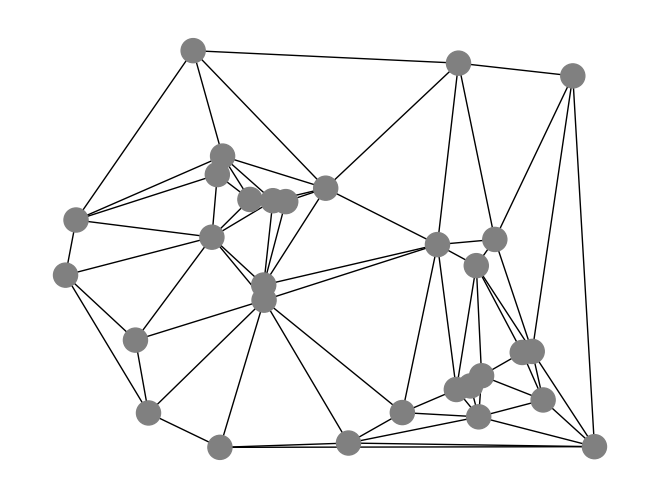

In [67]:
# toy instance
V, E = set(G.nodes), set(G.edges)
instance = GRSC_CB_Instance(V, E, points, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, d)

instance.draw_graph()


GRSC_CB_Instance(|V|=30, |E|=79, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2
Objective: 44.0
Nodes in the reserve (x): [1, 6, 12]
Nodes in the core (z): [1, 12]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


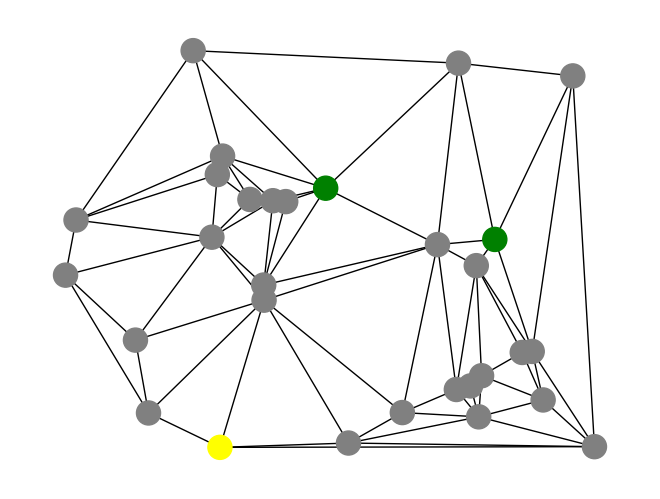

In [68]:
print(instance)
model = GRSC_CB_Model(instance)
model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=30, |E|=79, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2
Objective: 338.0
Nodes in the reserve (x): [2, 5, 11, 12, 18, 23, 25]
Nodes in the core (z): [2, 23]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


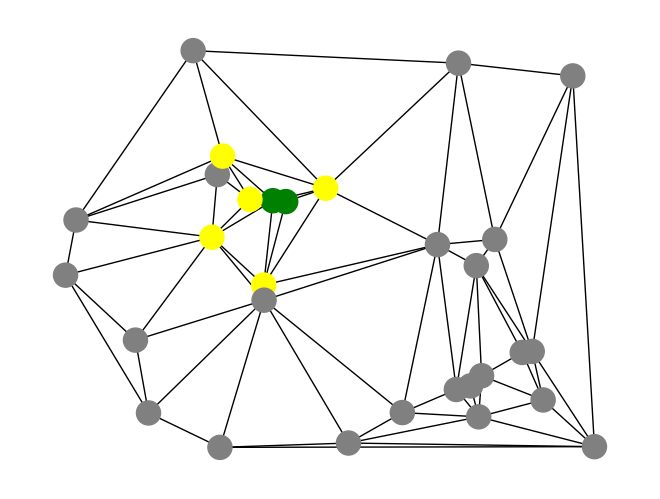

In [69]:
print(instance)
model = GRSC_CB_Model(instance, B=True)
model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=30, |E|=79, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2
Objective: 44.0
Nodes in the reserve (x): [1, 6, 12]
Nodes in the core (z): [1, 12]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


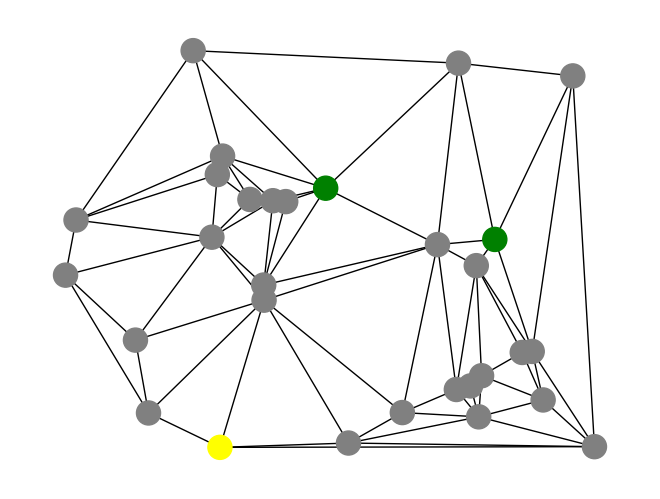

In [70]:
print(instance)
model = GRSC_CB_Model(instance, C=True)
model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=30, |E|=79, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Add constraint CORECON (integer): WV=[], WA=[0, 1, 2, 3, 4, 5, 6, np.int32(7), np.int32(8), 9, 10, 11, 12, 13, np.int32(14), 15, np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), 21, 22, np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29)], l=0
Add constraint CORECON (integer): WV=[6, np.int32(7), 8, np.int32(21), np.int32(26), 27], WA=[1, 4, np.int32(13), 17, np.int32(19), np.int32(20), np.int32(22), np.int32(28), np.int32(29)], l=1
Add constraint CORECON (integer): WV=[1, 6, np.int32(7), np.int32(8), 20, np.int32(21), np.int32(27)], WA=[0, 2, 3, 5, 9, 10, 11, 12, np.int32(14), 15, np.int32(16), np.int32(18), np.int32(23), np.int32(24), np.int32(25), np.int32(26)], l=0
Add constraint CORECON (integer): WV=[0, 5, 6, 7, 10, 11, 15, np.int32(26), np.int32(29)], WA=[16, np.int32(27)], l=16
Add constraint CORECON (i

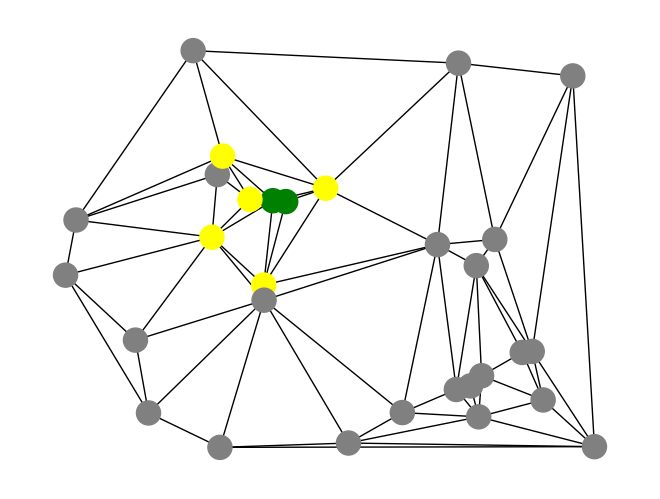

In [71]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=30, |E|=79, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[], WA=[0, 1, 2, 3, 4, 5, 6, np.int32(7), np.int32(8), 9, 10, 11, 12, 13, np.int32(14), 15, np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), 21, 22, np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29)], l=0
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32

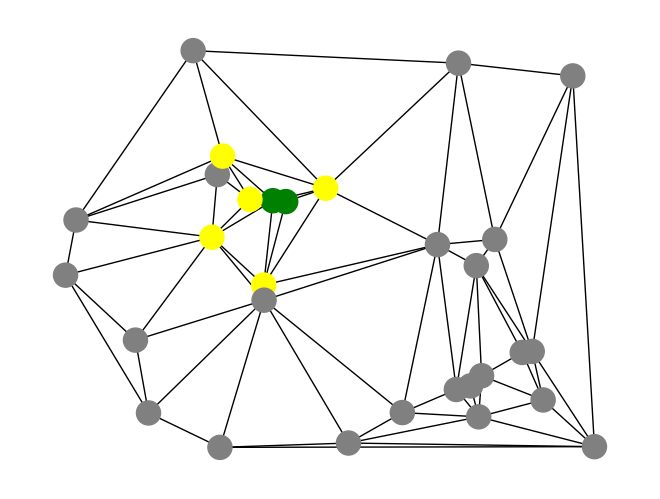

In [72]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True, cp_heuristic=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=30, |E|=79, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[], WA=[0, 1, 2, 3, 4, 5, 6, np.int32(7), np.int32(8), 9, 10, 11, 12, 13, np.int32(14), 15, np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), 21, 22, np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29)], l=0
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32(23)], l=12
Add constraint CORECON (integer): WV=[2, 5, 9, np.int32(21), np.int32(25), np.int32(26)], WA=[12, np.int32

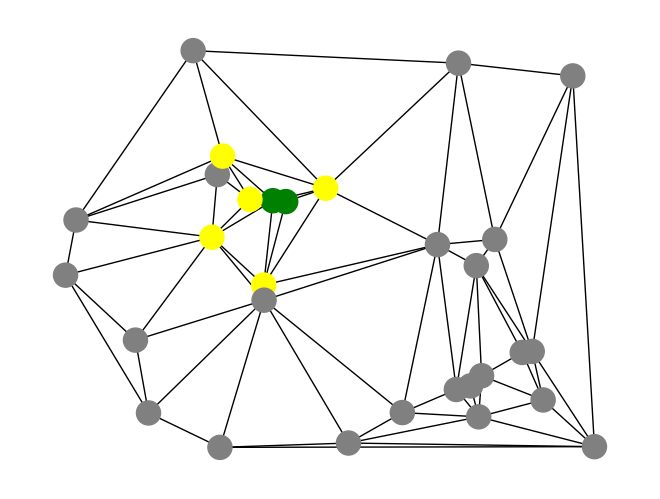

In [73]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True, cp_heuristic=True, lb_heuristic=True, verbose=True)
model.print_solution()
model.print_graph()